# Notebook 1 — Data Loading & Sanity Checks

This notebook loads the scraped lyrics dataset from SQLite into pandas, validates data quality, and produces a cleaned dataset for downstream analysis.

**Goals:**
- Quantify lyrics coverage across 80 years (1946–2024)
- Identify which scraper sources contributed at each era
- Spot-check lyrics quality for cleaning issues
- Save a deduplicated, validated dataframe for later notebooks

In [1]:
import sqlite3
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

DB_PATH = Path.cwd().parent / "data" / "songs.db"
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"DB: {DB_PATH}")
print(f"DB exists: {DB_PATH.exists()}")

DB: /Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/data/songs.db
DB exists: True


## Loading the data

We join the `songs` and `lyrics` tables. Some songs may have lyrics from multiple sources (if the pipeline was re-run with different fallback orders) — we keep the highest-priority source per song: Genius > AZLyrics > Lyrics.com.

In [2]:
SOURCE_PRIORITY = {"genius": 0, "azlyrics": 1, "lyrics_com": 2}

with sqlite3.connect(DB_PATH) as conn:
    songs = pd.read_sql("SELECT * FROM songs", conn)
    lyrics = pd.read_sql("SELECT * FROM lyrics", conn)

lyrics["source_rank"] = lyrics["source"].map(SOURCE_PRIORITY)
lyrics = (lyrics.sort_values("source_rank")
                .drop_duplicates(subset="song_id", keep="first")
                .drop(columns="source_rank"))

df = songs.merge(
    lyrics[["song_id", "source", "lyrics_text", "word_count", "url"]],
    left_on="id", right_on="song_id", how="left",
)
df["has_lyrics"] = df["lyrics_text"].notna()
df["decade"] = (df["year"] // 10) * 10

print(f"Total songs: {len(df):,}")
print(f"With lyrics: {df['has_lyrics'].sum():,} ({df['has_lyrics'].mean()*100:.1f}%)")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
df.head()

Total songs: 7,031
With lyrics: 6,711 (95.4%)
Year range: 1946–2024


,id,year,rank,title,artist,title_norm,artist_norm,chart_source,scraped_at,song_id,source,lyrics_text,word_count,url,has_lyrics,decade
0,1,2015,1,Uptown Funk,Mark Ronson featuring Bruno Mars,uptown funk,mark ronson,billboard_year_end,2026-05-13T11:20:13.995837+00:00,1.0,genius,"Doh\nDoh-doh-doh, doh-doh-doh, doh-doh\nDoh-do...",638.0,https://genius.com/Genius-traduzioni-italiane-...,True,2010
1,2,2015,2,Thinking Out Loud,Ed Sheeran,thinking out loud,ed sheeran,billboard_year_end,2026-05-13T11:20:13.996387+00:00,2.0,genius,When your legs don't work like they used to be...,325.0,https://genius.com/Ed-sheeran-thinking-out-lou...,True,2010
2,3,2015,3,See You Again,Wiz Khalifa featuring Charlie Puth,see you again,wiz khalifa,billboard_year_end,2026-05-13T11:20:13.996409+00:00,3.0,genius,"It's been a long day\nWithout you, my friend\n...",438.0,https://genius.com/Wiz-khalifa-see-you-again-l...,True,2010
3,4,2015,4,Trap Queen,Fetty Wap,trap queen,fetty wap,billboard_year_end,2026-05-13T11:20:13.996423+00:00,4.0,genius,"RGF Productions\nRemy Boyz, yah-ah\n1738, ayy\...",608.0,https://genius.com/Fetty-wap-trap-queen-lyrics,True,2010
4,5,2015,5,Sugar,Maroon 5,sugar,maroon 5,billboard_year_end,2026-05-13T11:20:13.996435+00:00,5.0,genius,"I'm hurtin', baby, I'm broken down\nI need you...",474.0,https://genius.com/Maroon-5-sugar-lyrics,True,2010


## Per-year coverage

The most important sanity check. Anything below 95% deserves investigation. We expect a sharp transition around 1958 — before that, Billboard had multiple competing charts with fewer entries, and lyrics-internet coverage of crooner/swing-era music is genuinely thin.

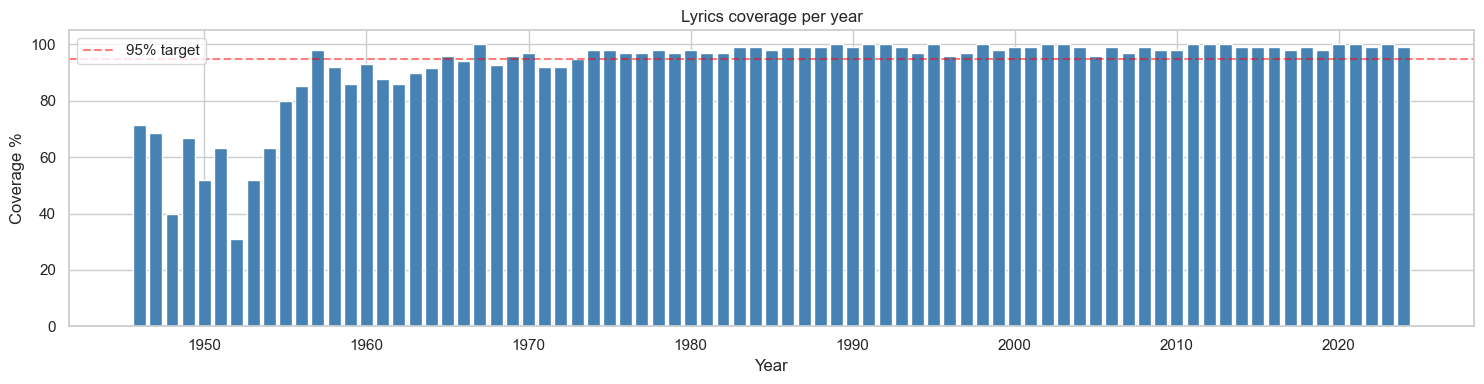

Worst years:


,total,with_lyrics,coverage
year,,,
1952,29,9,31.034483
1948,35,14,40.000000
1950,29,15,51.724138
1953,29,15,51.724138
1951,30,19,63.333333
1954,30,19,63.333333
1949,30,20,66.666667
1947,35,24,68.571429
1946,35,25,71.428571


In [3]:
year_stats = (df.groupby("year")
                .agg(total=("id", "count"),
                     with_lyrics=("has_lyrics", "sum"))
                .assign(coverage=lambda x: x["with_lyrics"] / x["total"] * 100))

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(year_stats.index, year_stats["coverage"], color="steelblue")
ax.axhline(95, color="red", linestyle="--", alpha=0.5, label="95% target")
ax.set_ylabel("Coverage %"); ax.set_xlabel("Year")
ax.set_title("Lyrics coverage per year")
ax.legend()
plt.tight_layout(); plt.show()

print("Worst years:")
year_stats.nsmallest(10, "coverage")

## Source contribution by decade

Which scraper earned its keep? Did AZLyrics matter more for older eras when Genius coverage thinned out?

Overall lyrics by source:
source
genius      6047
azlyrics     664
NaN          320
Name: count, dtype: int64


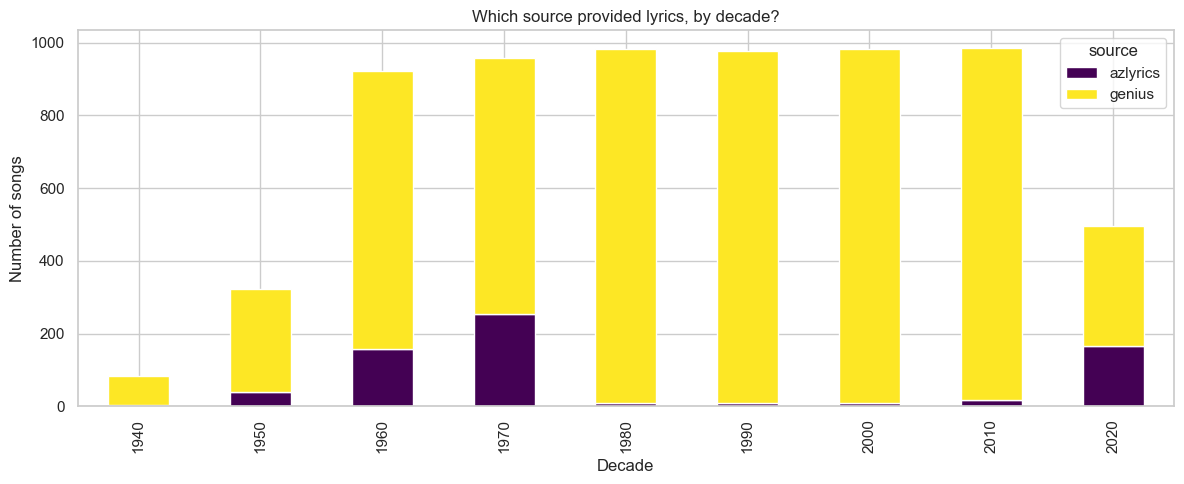

source,azlyrics,genius
decade,,
1940,4,79
1950,40,283
1960,157,764
1970,253,706
1980,8,974
1990,9,969
2000,10,973
2010,18,967
2020,165,332


In [4]:
source_counts = df["source"].value_counts(dropna=False)
print("Overall lyrics by source:")
print(source_counts)

decade_source = (df[df["has_lyrics"]]
                 .groupby(["decade", "source"]).size()
                 .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
decade_source.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Which source provided lyrics, by decade?")
ax.set_ylabel("Number of songs"); ax.set_xlabel("Decade")
plt.tight_layout(); plt.show()

decade_source

## Lyrics length distribution

Very short lyrics (<30 words) are typically scraper errors. Very long ones (>2000 words) are usually rap with multiple verses, but occasionally indicate concatenated/duplicated content.

Word count statistics:
count    6711.000000
mean      358.459842
std       192.905449
min        12.000000
25%       224.000000
50%       314.000000
75%       442.000000
max      2525.000000
Name: word_count, dtype: float64


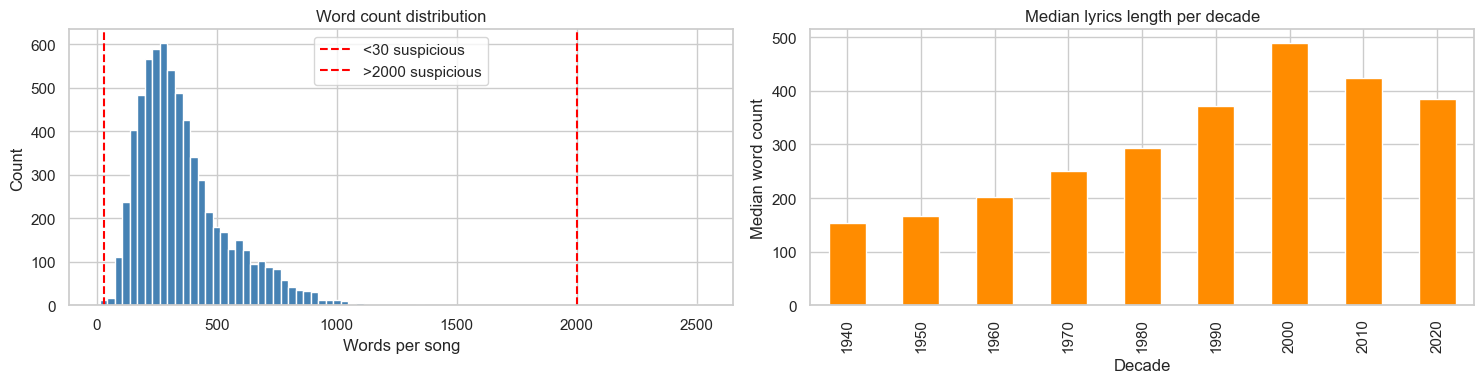

In [5]:
lyrics_df = df[df["has_lyrics"]].copy()
print("Word count statistics:")
print(lyrics_df["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(lyrics_df["word_count"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Word count distribution")
axes[0].set_xlabel("Words per song"); axes[0].set_ylabel("Count")
axes[0].axvline(30, color="red", linestyle="--", label="<30 suspicious")
axes[0].axvline(2000, color="red", linestyle="--", label=">2000 suspicious")
axes[0].legend()

length_by_decade = lyrics_df.groupby("decade")["word_count"].median()
length_by_decade.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Median lyrics length per decade")
axes[1].set_xlabel("Decade"); axes[1].set_ylabel("Median word count")
plt.tight_layout(); plt.show()

In [6]:
print("Suspiciously short lyrics (< 30 words):")
short = lyrics_df[lyrics_df["word_count"] < 30][
    ["year", "rank", "title", "artist", "word_count", "source"]
]
print(f"Count: {len(short)}")
short.head(20)

Suspiciously short lyrics (< 30 words):
Count: 4


,year,rank,title,artist,word_count,source
4458,1974,79,Tubular Bells,Mike Oldfield,26.0,genius
4538,1975,59,Express,B.T. Express,22.0,genius
6346,1963,10,Sukiyaki,Kyu Sakamoto,23.0,genius
6799,1967,67,Soul Finger,Bar-Kays,12.0,genius


## Quality spot-check across decades

Sample one song per decade and print the start of its lyrics. If lyrics from earlier decades look garbled or contain HTML, we have a cleaning bug.

In [7]:
for decade in sorted(lyrics_df["decade"].unique()):
    sample = lyrics_df[lyrics_df["decade"] == decade].sample(1, random_state=42).iloc[0]
    print(f"\n=== {decade}s — '{sample['title']}' by {sample['artist']} [{sample['source']}] ===")
    print(sample["lyrics_text"][:300].strip() + "...")


=== 1940s — 'That's My Desire' by Sammy Kaye [genius] ===
To spend one night with you
In our old rendezvous
And reminisce with you
That's my desire

To be where gypsies play
Down in that dim café
And dance till break of day
That's my desire

We'll sip a little glass of wine
I'll gaze into your eyes divine
I'll feel the touch of your lips
Pressing on mine...

=== 1950s — 'Moonlight Gambler' by Frankie Laine [genius] ===
You can gamble for matchsticks, you can gamble for gold
The stakes may be heavy or small
But if you haven't gambled for love, and lost
Then you haven't gambled at all

They call me a moonlight gambler
I've gambled for love, and lost
When I gamble for love and it isn't in the cards
Oh, what heartache...

=== 1960s — 'Deep Purple' by Nino Tempo & April Stevens [genius] ===
When the deep purple falls over sleepy garden walls
And the stars begin to twinkle in the night
In the mist of my memory, you wander on back to me
Breathing my name with a sigh

In the still of the nigh

## Save the clean dataset

We drop songs with very short lyrics (likely parse errors), reset the index, and save to parquet (fast binary format) + CSV (human-readable metadata). Notebooks 2+ will read from these files.

In [8]:
clean = lyrics_df[[
    "id", "year", "decade", "rank", "title", "artist",
    "title_norm", "artist_norm", "source", "url",
    "lyrics_text", "word_count",
]].copy()

before = len(clean)
clean = clean[clean["word_count"] >= 30]
clean = clean.reset_index(drop=True)
print(f"Dropped {before - len(clean)} songs with <30 words")

clean.to_parquet(PROCESSED_DIR / "songs_with_lyrics.parquet")
clean.drop(columns="lyrics_text").to_csv(
    PROCESSED_DIR / "songs_metadata.csv", index=False)

print(f"\nSaved {len(clean):,} songs to {PROCESSED_DIR}")
print(f"  songs_with_lyrics.parquet — full text, for ML notebooks")
print(f"  songs_metadata.csv — metadata only, for quick browsing")

Dropped 4 songs with <30 words

Saved 6,707 songs to /Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/data/processed
  songs_with_lyrics.parquet — full text, for ML notebooks
  songs_metadata.csv — metadata only, for quick browsing
